<a href="https://colab.research.google.com/github/IrisCheon/NLP-practice/blob/main/BBC_News_Classificaion.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#BBC News Classification

In [11]:
import kagglehub

# Download latest version
path = kagglehub.competition_download('learn-ai-bbc')

print("Path to competition files:", path)

100%|██████████| 1.85M/1.85M [00:00<00:00, 131MB/s]

Extracting files...
Path to competition files: /root/.cache/kagglehub/competitions/learn-ai-bbc


In [13]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os

In [14]:
print(os.listdir(path))

['BBC News Sample Solution.csv', 'BBC News Train.csv', 'BBC News Test.csv']


In [18]:
df = pd.read_csv(os.path.join(path, 'BBC News Train.csv'))

#데이터 확인

In [19]:
df.head()

,ArticleId,Text,Category
0,1833,worldcom ex-boss launches defence lawyers defe...,business
1,154,german business confidence slides german busin...,business
2,1101,bbc poll indicates economic gloom citizens in ...,business
3,1976,lifestyle governs mobile choice faster bett...,tech
4,917,enron bosses in $168m payout eighteen former e...,business


In [20]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1490 entries, 0 to 1489
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   ArticleId  1490 non-null   int64 
 1   Text       1490 non-null   object
 2   Category   1490 non-null   object
dtypes: int64(1), object(2)
memory usage: 35.1+ KB


In [22]:
df.shape

(1490, 3)

#EDA

In [23]:
df.columns

Index(['ArticleId', 'Text', 'Category'], dtype='object')

In [25]:
df["Category"].value_counts().sort_index()

,count
Category,
business,336
entertainment,273
politics,274
sport,346
tech,261


In [26]:
df["Text_length"] = df["Text"].str.split().str.len()

df.head()

,ArticleId,Text,Category,Text_length
0,1833,worldcom ex-boss launches defence lawyers defe...,business,301
1,154,german business confidence slides german busin...,business,325
2,1101,bbc poll indicates economic gloom citizens in ...,business,514
3,1976,lifestyle governs mobile choice faster bett...,tech,634
4,917,enron bosses in $168m payout eighteen former e...,business,355


In [30]:
df.groupby("Category")["Text_length"].mean().sort_values(ascending=False)

,Text_length
Category,
tech,501.858238
politics,449.689781
sport,335.346821
business,334.169643
entertainment,333.912088


In [48]:
df.groupby("Category")["Text_length"].describe()

,count,mean,std,min,25%,50%,75%,max
Category,,,,,,,,
business,336.0,334.169643,133.527272,145.0,253.00,304.0,391.25,902.0
entertainment,273.0,333.912088,203.887349,144.0,229.00,272.0,380.00,2448.0
politics,274.0,449.689781,258.836242,90.0,319.25,441.5,527.00,3345.0
sport,346.0,335.346821,185.443084,116.0,210.25,294.5,412.75,1671.0
tech,261.0,501.858238,211.672986,188.0,340.00,457.0,633.00,1549.0


In [46]:
df_text_category = df.groupby("Category")["Text_length"].describe()[[ "mean", "std", "50%"]]
df_text_category

,mean,std,50%
Category,,,
business,334.169643,133.527272,304.0
entertainment,333.912088,203.887349,272.0
politics,449.689781,258.836242,441.5
sport,335.346821,185.443084,294.5
tech,501.858238,211.672986,457.0


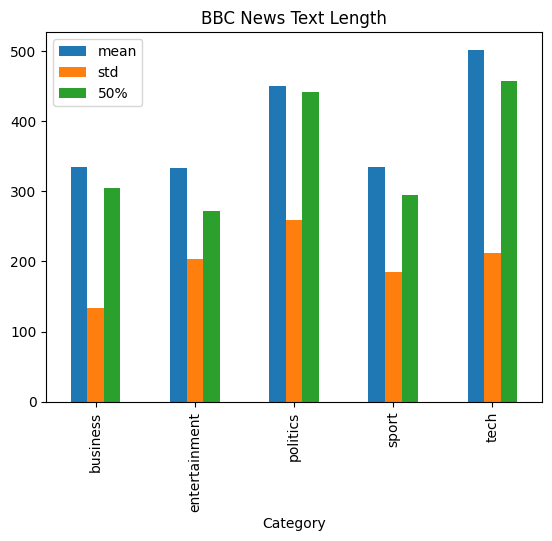

In [47]:
df_text_category.plot(kind="bar")
plt.title("BBC News Text Length")
plt.show()

# TF-IDF

In [49]:
from sklearn.feature_extraction.text import TfidfVectorizer

In [50]:
vectorizer = TfidfVectorizer(
    stop_words = "english",
    min_df = 5,
    max_df = 0.8,
    max_features = 5000
)

tfidf_matrix = vectorizer.fit_transform(
     df["Text"]
)

feature_names = vectorizer.get_feature_names_out()

In [52]:
tfidf_df = pd.DataFrame(
    tfidf_matrix.toarray(),
    columns = feature_names,
    index = df.index
)

In [53]:
category_tfidf = (
    tfidf_df.assign(category = df["Category"])
    .groupby("category")
    .mean()
)

In [56]:
for category in category_tfidf.index:
    top_words = (
        category_tfidf.loc[category]
        .sort_values(ascending = False)
        .head(15)
    )

    print(f"\n[{category}]")
    print(top_words)


[business]
growth        0.034737
market        0.032035
firm          0.031366
bank          0.031318
economy       0.031254
year          0.029941
company       0.028779
shares        0.028283
mr            0.028142
oil           0.027872
sales         0.027345
economic      0.025886
2004          0.023249
dollar        0.021973
government    0.021241
Name: business, dtype: float64

[entertainment]
film        0.090232
best        0.051186
music       0.036743
band        0.034807
awards      0.032078
actor       0.030425
award       0.029133
star        0.028291
album       0.027420
festival    0.026979
year        0.026882
films       0.025349
tv          0.024827
singer      0.024701
oscar       0.024071
Name: entertainment, dtype: float64

[politics]
mr            0.089071
labour        0.069308
election      0.060811
blair         0.058768
party         0.050589
government    0.048601
brown         0.039795
minister      0.036230
howard        0.031708
people        0.028758
pr

In [57]:
top_words_dict = {}

for category in category_tfidf.index:
    top_words = (
        category_tfidf.loc[category]
        .sort_values(ascending = False)
        .head(10)
        .index
        .tolist()
    )
    top_words_dict[category] = top_words

top_words_df = pd.DataFrame(top_words_dict)

top_words_df

,business,entertainment,politics,sport,tech
0,growth,film,mr,england,people
1,market,best,labour,game,mobile
2,firm,music,election,win,software
3,bank,band,blair,cup,users
4,economy,awards,party,match,technology
5,year,actor,government,chelsea,microsoft
6,company,award,brown,team,net
7,shares,star,minister,players,phone
8,mr,album,howard,season,digital
9,oil,festival,people,world,computer
